In [1]:
import os, zipfile, random, shutil
import torch
import torchvision
from torchvision import transforms
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda


In [7]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# CIFAR10 images are 32x32
tfms_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

tfms_test = transforms.Compose([
    transforms.ToTensor(),
])

train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfms_train)
test_full  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tfms_test)

print("CIFAR10 classes:", train_full.classes)

Device: cuda


100%|██████████| 170M/170M [00:04<00:00, 42.1MB/s]


CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
CAT_ID = 3
DOG_ID = 5

def filter_cat_dog(dataset):
    idxs = []
    new_labels = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        if y == CAT_ID or y == DOG_ID:
            idxs.append(i)
            new_labels.append(0 if y == CAT_ID else 1)  # cat=0, dog=1
    return idxs, new_labels

train_idxs, _ = filter_cat_dog(train_full)
test_idxs, _  = filter_cat_dog(test_full)

train_ds = Subset(train_full, train_idxs)
test_ds  = Subset(test_full, test_idxs)

print("Train cat+dog images:", len(train_ds))
print("Test cat+dog images:", len(test_ds))

Train cat+dog images: 10000
Test cat+dog images: 2000


In [9]:
# Update transforms with resize for ResNet
tfms_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

tfms_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=tfms_train)
test_full  = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=tfms_test)

train_idxs, _ = filter_cat_dog(train_full)
test_idxs, _  = filter_cat_dog(test_full)

train_ds = Subset(train_full, train_idxs)
test_ds  = Subset(test_full, test_idxs)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

class_names = ["cat", "dog"]
print("Ready:", class_names)

Ready: ['cat', 'dog']


In [10]:
import torch.nn as nn
import torch.optim as optim

model = torchvision.models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def simple_acc(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

epochs = 2  # keep small for first run

for epoch in range(1, epochs+1):
    model.train()
    train_loss, train_acc = 0, 0

    for x, y_raw in train_loader:
        # y_raw contains original CIFAR labels (3 or 5), convert to 0/1
        y = torch.where(y_raw == CAT_ID, torch.tensor(0), torch.tensor(1))

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += simple_acc(out, y)

    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)

    model.eval()
    test_loss, test_acc = 0, 0
    with torch.no_grad():
        for x, y_raw in test_loader:
            y = torch.where(y_raw == CAT_ID, torch.tensor(0), torch.tensor(1))
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()
            test_acc  += simple_acc(out, y)

    test_loss /= len(test_loader)
    test_acc  /= len(test_loader)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.2MB/s]


Epoch 1: train_loss=0.2768, train_acc=0.8811 | test_loss=0.2378, test_acc=0.8988
Epoch 2: train_loss=0.1530, train_acc=0.9385 | test_loss=0.2089, test_acc=0.9107


In [11]:
torch.save(model.state_dict(), "resnet18_cifar_cat_dog.pth")
print("Saved: resnet18_cifar_cat_dog.pth")

Saved: resnet18_cifar_cat_dog.pth


Saving cat1.png to cat1.png


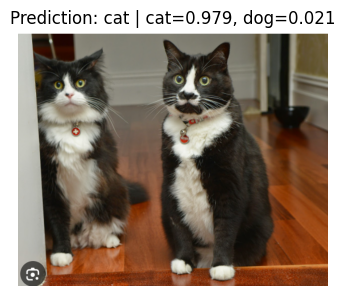

In [15]:
from google.colab import files
from PIL import Image

infer_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = infer_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
    return img, pred, probs

uploaded = files.upload()

for fname in uploaded.keys():
    img, pred, probs = predict_image(fname)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]} | cat={probs[0]:.3f}, dog={probs[1]:.3f}")
    plt.show()

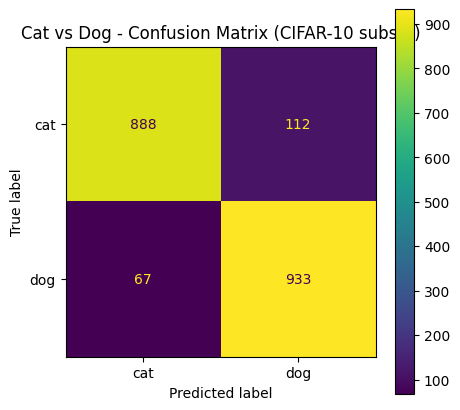

              precision    recall  f1-score   support

         cat       0.93      0.89      0.91      1000
         dog       0.89      0.93      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

Saved results/ files ✅


In [16]:
!pip -q install scikit-learn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x, y_raw in test_loader:
        y = torch.where(y_raw == CAT_ID, torch.tensor(0), torch.tensor(1))
        x = x.to(device)

        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
os.makedirs("results", exist_ok=True)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, values_format="d")
plt.title("Cat vs Dog - Confusion Matrix (CIFAR-10 subset)")
plt.savefig("results/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open("results/classification_report.txt", "w") as f:
    f.write(report)

print("Saved results/ files ✅")

In [17]:
from google.colab import files
files.download("resnet18_cifar_cat_dog.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
files.download("results/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
files.download("results/classification_report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>